
# 8.1: From MEG sensor-space data to HNN simulation

This example demonstrates how to calculate an inverse solution of the median
nerve evoked response potential (ERP) in S1 from the MNE somatosensory dataset,
and then simulate a biophysical model network that reproduces the observed
dynamics. Note that we do not expound on how we came up with the sequence of
evoked drives used in this example, rather, we only demonstrate its
implementation. For those who want more background on the HNN model and the
process used to articulate the proximal and distal drives needed to simulate
evoked responses, see the [HNN ERP tutorial](https://jonescompneurolab.github.io/textbook/content/05_erps/erp_overview.html). The sequence of evoked drives
presented here is not part of a current publication but is motivated by prior
studies (Jones et al., 2007), (Neymotin et al., 2020).

In [1]:
# Authors: Mainak Jas <mainakjas@gmail.com>
#          Ryan Thorpe <ryan_thorpe@brown.edu>

Note: This specific notebook requires the installation of several other, non-HNN packages in order to run and plot MNE output properly. **If you un-comment the next cell, it will install these packages into your Python environment automatically.**

In [2]:
# %pip install -q mne nibabel ipyevents "pyvista[all]" pyvistaqt pooch==1.8.2

In [3]:
# Needed for certain plotting to work
import pyvista as pv
from mne.viz import set_3d_backend
set_3d_backend('notebook')
pv.set_jupyter_backend('client')

Using notebook 3d backend.


We will import the packages needed for computing the inverse solution
from the MNE somatosensory dataset. `MNE`, and its dependency `NiBabel`
should have been installed using the previous `pip` command. The
somatosensory dataset can be downloaded by importing ``somato`` from
``mne.datasets``.

In [4]:
import os.path as op
import matplotlib.pyplot as plt

import mne
from mne.datasets import somato
from mne.minimum_norm import apply_inverse, make_inverse_operator

Now we set the the path of the ``somato`` dataset for subject `01`.



In [5]:
data_path = somato.data_path()
subject = '01'
task = 'somato'
raw_fname = op.join(data_path, 'sub-{}'.format(subject), 'meg',
                    'sub-{}_task-{}_meg.fif'.format(subject, task))
fwd_fname = op.join(data_path, 'derivatives', 'sub-{}'.format(subject),
                    'sub-{}_task-{}-fwd.fif'.format(subject, task))
subjects_dir = op.join(data_path, 'derivatives', 'freesurfer', 'subjects')

Then, we load the raw data and estimate the inverse operator.



In [6]:
# Read and band-pass filter the raw data
raw = mne.io.read_raw_fif(raw_fname, preload=True)
l_freq, h_freq = 1, 40
raw.filter(l_freq, h_freq)

# Identify stimulus events associated with MEG time series in the dataset
events = mne.find_events(raw, stim_channel='STI 014')

# Define epochs within the time series
event_id, tmin, tmax = 1, -.2, .17
baseline = None
epochs = mne.Epochs(raw, events, event_id, tmin, tmax, baseline=baseline,
                    reject=dict(grad=4000e-13, eog=350e-6), preload=True)

# Compute the inverse operator
fwd = mne.read_forward_solution(fwd_fname)
cov = mne.compute_covariance(epochs)
inv = make_inverse_operator(epochs.info, fwd, cov)

Opening raw data file /Users/austinsoplata/mne_data/MNE-somato-data/sub-01/meg/sub-01_task-somato_meg.fif...
    Range : 237600 ... 506999 =    791.189 ...  1688.266 secs
Ready.
Reading 0 ... 269399  =      0.000 ...   897.077 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 993 samples (3.307 s)

Finding events on: STI 014
111 events found on stim channel STI 014
Event IDs: [1]
Not setting metadata
111 matching events found
No baseline correction applied
0 projection items activated
Using data fro

/var/folders/cs/5b2dq2192v52fd3j8ppbtcg80000gp/T/ipykernel_71700/1661918444.py:17: RuntimeWarning: Something went wrong in the data-driven estimation of the data rank as it exceeds the theoretical rank from the info (306 > 64). Consider setting rank to "auto" or setting it explicitly as an integer.
  cov = mne.compute_covariance(epochs)


Estimating covariance using EMPIRICAL
Done.
Number of samples used : 12432
[done]
Converting forward solution to surface orientation
    No patch info available. The standard source space normals will be employed in the rotation to the local surface coordinates....
    Converting to surface-based source orientations...
    [done]
Computing inverse operator with 306 channels.
    306 out of 306 channels remain after picking
Selected 306 channels
Creating the depth weighting matrix...
    204 planar channels
    limit = 7615/8155 = 10.004172
    scale = 5.17919e-08 exp = 0.8
Applying loose dipole orientations to surface source spaces: 0.2
Whitening the forward solution.
Computing rank from covariance with rank=None
    Using tolerance 2e-12 (2.2e-16 eps * 306 dim * 29  max singular value)
    Estimated rank (mag + grad): 64
    MEG: rank 64 computed from 306 data channels with 0 projectors
    Setting small MEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjus

There are several methods to do source reconstruction. Some of the methods
such as MNE are distributed source methods whereas dipole fitting will
estimate the location and amplitude of a single current dipole. At the
moment, we do not offer explicit recommendations on which source
reconstruction technique is best for HNN. However, we do want our users
to note that the dipole currents simulated with HNN are assumed to be normal
to the cortical surface. Hence, using the option "pick_ori='normal'" is
appropriate.

In [7]:
snr = 3.
lambda2 = 1. / snr ** 2
evoked = epochs.average()
stc = apply_inverse(evoked, inv, lambda2, method='MNE',
                    pick_ori="normal", return_residual=False,
                    verbose=True)

Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 111
    Created the regularized inverter
    The projection vectors do not apply to these channels.
    Created the whitener using a noise covariance matrix with rank 64 (242 small eigenvalues omitted)
Applying inverse operator to "1"...
    Picked 306 channels from the data
    Computing inverse...
    Eigenleads need to be weighted ...
    Computing residual...
    Explained  86.1% variance
[done]


To extract the primary response in primary somatosensory cortex (S1), we
create a label for the postcentral gyrus (S1) in source-space



In [8]:
hemi = 'rh'
label_tag = 'G_postcentral'
label_s1 = mne.read_labels_from_annot(subject, parc='aparc.a2009s', hemi=hemi,
                                      regexp=label_tag,
                                      subjects_dir=subjects_dir)[0]

Reading labels from parcellation...
   read 1 labels from /Users/austinsoplata/mne_data/MNE-somato-data/derivatives/freesurfer/subjects/01/label/rh.aparc.a2009s.annot


Visualizing the distributed S1 activation in reference to the geometric
structure of the cortex (i.e., plotted on a structural MRI) can help us
figure out how to orient the dipole. Note that in the HNN framework,
positive and negative deflections of a current dipole source correspond to
upwards (from deep to superficial) and downwards (from superficial to deep)
current flow, respectively. Uncomment the following code to open an
interactive 3D render of the brain and its surface activation (requires the
``pyvista`` python library). You should get 2 plots, the first showing the
post-central gyrus label from which the dipole time course was extracted and
the second showing MNE activation at 0.040 sec that resemble the following
images.



In [9]:
'''
Brain = mne.viz.get_brain_class()
brain_label = Brain(subject, hemi, 'white', subjects_dir=subjects_dir)
brain_label.add_label(label_s1, color='green', alpha=0.9)
stc_label = stc.in_label(label_s1)
brain = stc_label.plot(subjects_dir=subjects_dir, hemi=hemi, surface='white',
                       view_layout='horizontal', initial_time=0.04,
                       backend='pyvista')
'''

"\nBrain = mne.viz.get_brain_class()\nbrain_label = Brain(subject, hemi, 'white', subjects_dir=subjects_dir)\nbrain_label.add_label(label_s1, color='green', alpha=0.9)\nstc_label = stc.in_label(label_s1)\nbrain = stc_label.plot(subjects_dir=subjects_dir, hemi=hemi, surface='white',\n                       view_layout='horizontal', initial_time=0.04,\n                       backend='pyvista')\n"

![mne_label_fig](https://user-images.githubusercontent.com/20212206/106524603-cfe75c80-64b0-11eb-9607-3415195c3e7a.png)

![mne_activity_fig](https://user-images.githubusercontent.com/20212206/106524542-b514e800-64b0-11eb-835e-497454e75eb9.png)

Now we extract the representative time course of dipole activation in our
labeled brain region using "mode='pca_flip'" (see [this MNE-python
example](https://mne.tools/stable/auto_examples/inverse/plot_label_source_activations.html) for more details). Note that the most prominent component of the
median nerve response occurs in the posterior wall of the central sulcus at
~0.040 sec. Since the dipolar activity here is negative, we orient the
extracted waveform so that the deflection at ~0.040 sec is pointed downwards.
Thus, the ~0.040 sec deflection corresponds to current flow traveling from
superficial to deep layers of cortex.



Extracting time courses for 1 labels (mode: pca_flip)


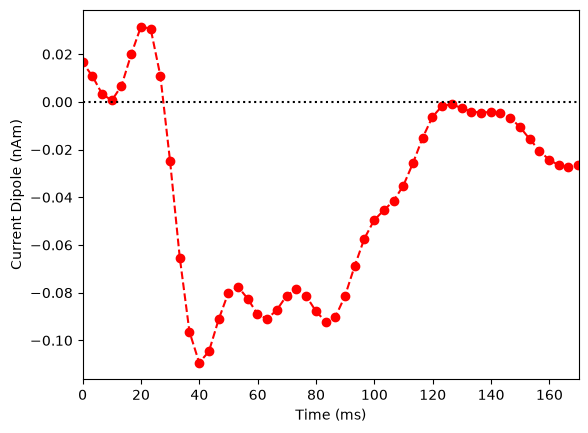

In [10]:
flip_data = stc.extract_label_time_course(label_s1, inv['src'],
                                          mode='pca_flip')
dipole_tc = -flip_data[0] * 1e9

plt.figure()
plt.plot(1e3 * stc.times, dipole_tc, 'ro--')
plt.xlabel('Time (ms)')
plt.ylabel('Current Dipole (nAm)')
plt.xlim((0, 170))
plt.axhline(0, c='k', ls=':')
plt.show()

Now, let us try to simulate the same with ``hnn-core``. We read in the
network parameters from ``N20.json`` and instantiate the network.



In [11]:
import hnn_core
from hnn_core import simulate_dipole, jones_2009_model
from hnn_core import average_dipoles, JoblibBackend

hnn_core_root = op.dirname(hnn_core.__file__)
params_fname = op.join(hnn_core_root, 'param', 'N20.json')
net = jones_2009_model(params_fname)

--No graphics will be displayed.


To simulate the source of the median nerve evoked response, we add a
sequence of synchronous evoked drives: 1 proximal, 2 distal, and 1 final
proximal drive. In order to understand the physiological implications of
proximal and distal drive as well as the general process used to articulate
a sequence of exogenous drive for simulating evoked responses, see the
[HNN ERP tutorial](https://jonescompneurolab.github.io/textbook/content/05_erps/erp_overview.html). Note that setting ``n_drive_cells=1`` and
``cell_specific=False`` creates a drive with synchronous input across cells
in the network.



In [12]:
# Early proximal drive
weights_ampa_p = {'L2_basket': 0.0036, 'L2_pyramidal': 0.0039,
                  'L5_basket': 0.0019, 'L5_pyramidal': 0.0020}
weights_nmda_p = {'L2_basket': 0.0029, 'L2_pyramidal': 0.0005,
                  'L5_basket': 0.0030, 'L5_pyramidal': 0.0019}
synaptic_delays_p = {'L2_basket': 0.1, 'L2_pyramidal': 0.1,
                     'L5_basket': 1.0, 'L5_pyramidal': 1.0}

net.add_evoked_drive(
    'evprox1', mu=21., sigma=4., numspikes=1, location='proximal',
    n_drive_cells=1, cell_specific=False, weights_ampa=weights_ampa_p,
    weights_nmda=weights_nmda_p, synaptic_delays=synaptic_delays_p,
    event_seed=276)

# Late proximal drive
weights_ampa_p = {'L2_basket': 0.003, 'L2_pyramidal': 0.0039,
                  'L5_basket': 0.004, 'L5_pyramidal': 0.0020}
weights_nmda_p = {'L2_basket': 0.001, 'L2_pyramidal': 0.0005,
                  'L5_basket': 0.002, 'L5_pyramidal': 0.0020}
synaptic_delays_p = {'L2_basket': 0.1, 'L2_pyramidal': 0.1,
                     'L5_basket': 1.0, 'L5_pyramidal': 1.0}

net.add_evoked_drive(
    'evprox2', mu=134., sigma=4.5, numspikes=1, location='proximal',
    n_drive_cells=1, cell_specific=False, weights_ampa=weights_ampa_p,
    weights_nmda=weights_nmda_p, synaptic_delays=synaptic_delays_p,
    event_seed=276)

# Early distal drive
weights_ampa_d = {'L2_basket': 0.0043, 'L2_pyramidal': 0.0032,
                  'L5_pyramidal': 0.0009}
weights_nmda_d = {'L2_basket': 0.0029, 'L2_pyramidal': 0.0051,
                  'L5_pyramidal': 0.0010}
synaptic_delays_d = {'L2_basket': 0.1, 'L2_pyramidal': 0.1,
                     'L5_pyramidal': 0.1}

net.add_evoked_drive(
    'evdist1', mu=32., sigma=2.5, numspikes=1, location='distal',
    n_drive_cells=1, cell_specific=False, weights_ampa=weights_ampa_d,
    weights_nmda=weights_nmda_d, synaptic_delays=synaptic_delays_d,
    event_seed=277)

# Late distal drive
weights_ampa_d = {'L2_basket': 0.0041, 'L2_pyramidal': 0.0019,
                  'L5_pyramidal': 0.0018}
weights_nmda_d = {'L2_basket': 0.0032, 'L2_pyramidal': 0.0018,
                  'L5_pyramidal': 0.0017}
synaptic_delays_d = {'L2_basket': 0.1, 'L2_pyramidal': 0.1,
                     'L5_pyramidal': 0.1}

net.add_evoked_drive(
    'evdist2', mu=84., sigma=4.5, numspikes=1, location='distal',
    n_drive_cells=1, cell_specific=False, weights_ampa=weights_ampa_d,
    weights_nmda=weights_nmda_d, synaptic_delays=synaptic_delays_d,
    event_seed=275)

Now we run the simulation over 2 trials so that we can plot the average
aggregate dipole. For a better match to the empirical waveform, set
``n_trials`` to be >=25.



In [13]:
n_trials = 2
# n_trials = 25
with JoblibBackend(n_jobs=2):
    dpls = simulate_dipole(net, tstop=170., n_trials=n_trials)

Joblib will run 2 trial(s) in parallel by distributing trials over 2 jobs.


--No graphics will be displayed.
--No graphics will be displayed.


Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
[Done]
[Done]
Trial 1: 0.03 ms...
Trial 2: 0.03 ms...
Trial 1: 10.0 ms...
Trial 2: 10.0 ms...
Trial 1: 20.0 ms...
Trial 2: 20.0 ms...
Trial 2: 30.0 ms...
Trial 1: 30.0 ms...
Trial 2: 40.0 ms...
Trial 1: 40.0 ms...
Trial 2: 50.0 ms...
Trial 1: 50.0 ms...
Trial 2: 60.0 ms...
Trial 1: 60.0 ms...
Trial 2: 70.0 ms...
Trial 1: 70.0 ms...
Trial 2: 80.0 ms...
Trial 1: 80.0 ms...
Trial 2: 90.0 ms...
Trial 1: 90.0 ms...
Trial 2: 100.0 ms...
Trial 1: 100.0 ms...
Trial 2: 110.0 ms...
Trial 1: 110.0 ms...
Trial 2: 120.0 ms...
Trial 1: 120.0 ms...
Trial 2: 130.0 ms...
Trial 1: 130.0 ms...
Trial 2: 140.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 2: 150.0 

Since the model is a reduced representation of the larger network
contributing to the response, the model response is noisier than it would be
in the net activity from a larger network where these effects are averaged
out, and the dipole amplitude is smaller than the recorded data. The
post-processing steps of smoothing and scaling the simulated dipole response
allow us to more accurately approximate the true signal responsible for the
recorded macroscopic evoked response (Jones et al., 2009) (Neymotin et al., 2020).

In [14]:
dpl_smooth_win = 20
dpl_scalefctr = 12
for dpl in dpls:
    dpl.smooth(dpl_smooth_win)
    dpl.scale(dpl_scalefctr)

Finally, we plot the driving spike histogram, empirical and simulated median
nerve evoked response waveforms, and output spike histogram.



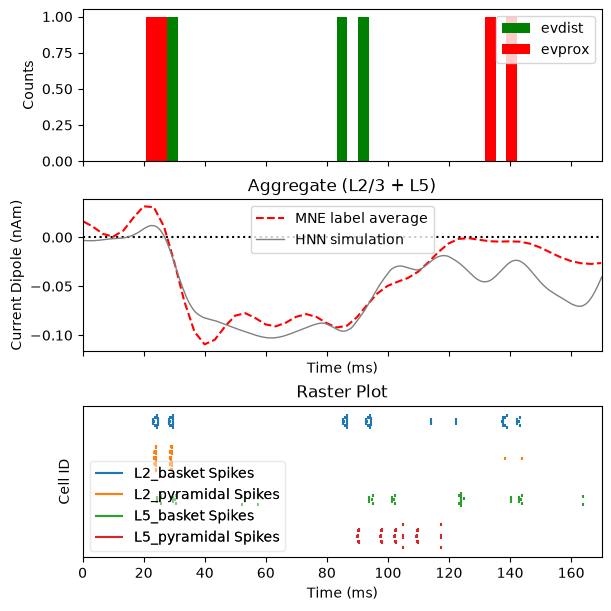

In [15]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(6, 6),
                         constrained_layout=True)
net.cell_response.plot_spikes_hist(ax=axes[0],
                                   spike_types=['evprox', 'evdist'],
                                   show=False)
axes[1].axhline(0, c='k', ls=':', label='_nolegend_')
axes[1].plot(1e3 * stc.times, dipole_tc, 'r--')
average_dipoles(dpls).plot(ax=axes[1], show=False)
axes[1].legend(['MNE label average', 'HNN simulation'])
axes[1].set_ylabel('Current Dipole (nAm)')
net.cell_response.plot_spikes_raster(ax=axes[2], show=False)
plt.show()

## References

Jones, S. R., Pritchett, D. L., Stufflebeam, S. M., Hämäläinen, M.
   & Moore, C. I. Neural correlates of tactile detection: a combined
   magnetoencephalography and biophysically based computational modeling
   study. J. Neurosci. 27, 10751–10764 (2007).
   [https://doi.org/10.1523/JNEUROSCI.0482-07.2007](https://doi.org/10.1523/JNEUROSCI.0482-07.2007)

Neymotin SA, Daniels DS, Caldwell B, McDougal RA, Carnevale NT,
   Jas M, Moore CI, Hines ML, Hämäläinen M, Jones SR. Human Neocortical
   Neurosolver (HNN), a new software tool for interpreting the cellular and
   network origin of human MEG/EEG data. eLife 9, e51214 (2020).
   [https://doi.org/10.7554/eLife.51214](https://doi.org/10.7554/eLife.51214)

